In [ ]:
# Importing the necessary libraries
from statsmodels.stats import outliers_influence
from ISLP import load_data
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt


In [25]:
# Load the dataset
data = pd.read_csv("data_cleaned.csv")  # Update with the correct file path

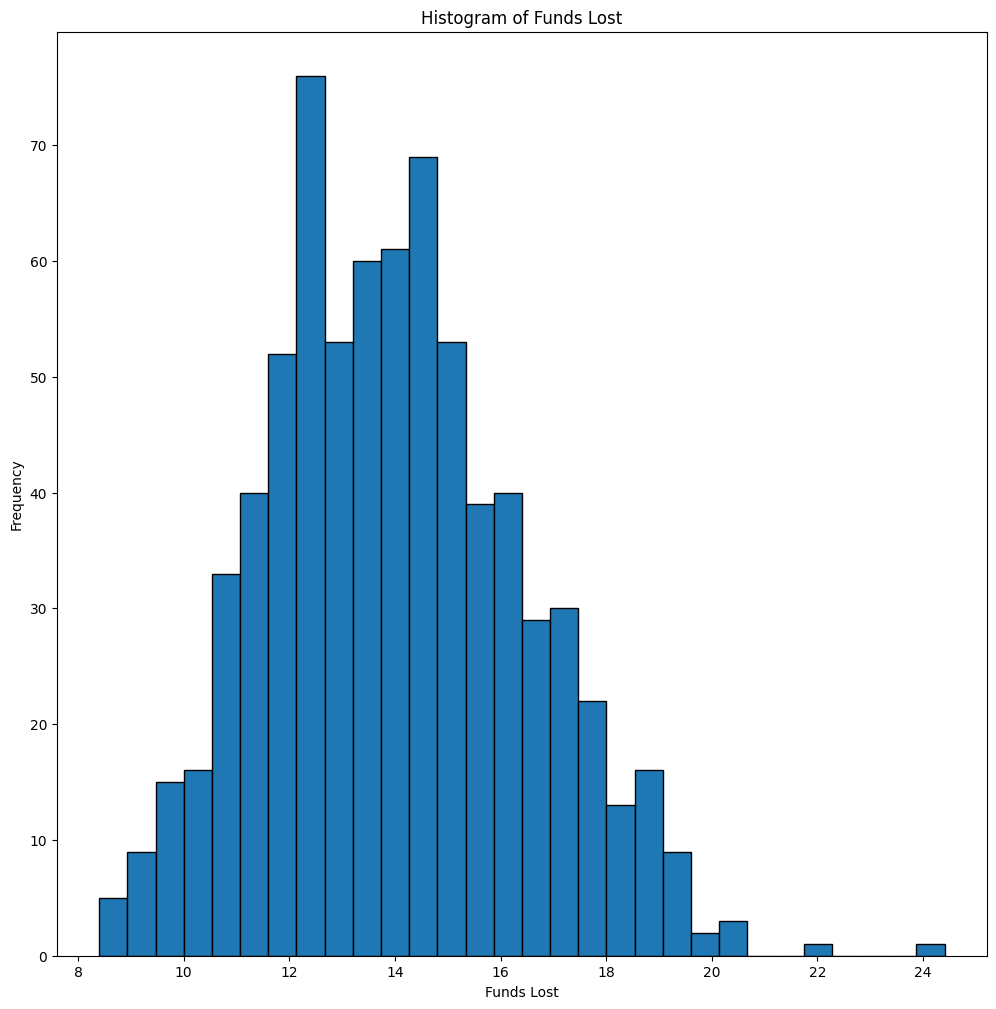

In [ ]:
data['Funds Lost'] = np.log(data['Funds.Lost'])
# Add labels and title
ax = plt.subplots(figsize=(12,12))[1]
plt.hist(data['Funds Lost'], bins=30, edgecolor='black')
plt.xlabel('Funds Lost')
plt.ylabel('Frequency')
plt.title('Histogram of Funds Lost')
plt.show()


In [27]:
# Training features (X) and target (y)
from ISLP.models import (ModelSpec as MS, summarize, poly)

data = data.drop(columns=['Quick Summary', 'Details', 'Tokens', 'Date', 'Funds.Lost'])

# Assuming 'data' is your DataFrame
data = pd.get_dummies(data, drop_first=True)


In [28]:
# Generate summary statistics

# Option 1: Use pandas to set float formatting (for the whole session)
pd.set_option('display.float_format', '{:.3f}'.format)

# Specify the statistics you want to include
summary_stats = data.drop(columns=['Funds Lost']).agg(['mean', 'std', 'min', 'max'])

sum_rounded  = summary_stats.round(3)

# Transpose the summary statistics
transposed_summary = sum_rounded.T

# Export to LaTeX
latex_table = transposed_summary.to_latex()

print(latex_table)

# Optionally, you can export the LaTeX table directly to a file
transposed_summary.to_latex('summary_statistics_table1.tex')

\begin{tabular}{lllll}
\toprule
 & mean & std & min & max \\
\midrule
Year & 2021.360000 & 2.656000 & 2011.000000 & 2024.000000 \\
Category_Bridge & 0.034806 & 0.183411 & False & True \\
Category_CeFi & 0.143240 & 0.350552 & False & True \\
Category_Exchange & 0.143240 & 0.350552 & False & True \\
Category_GamingM & 0.038822 & 0.193300 & False & True \\
Category_NFT & 0.054886 & 0.227911 & False & True \\
Category_Other & 0.234270 & 0.423826 & False & True \\
Category_Stablecoin & 0.025435 & 0.157548 & False & True \\
Category_Token & 0.119143 & 0.324174 & False & True \\
Category_YieldAggr & 0.095047 & 0.293476 & False & True \\
Issue_FlashLoanAttack & 0.159304 & 0.366204 & False & True \\
Issue_OracleIssue & 0.022758 & 0.149230 & False & True \\
Issue_Other & 0.485944 & 0.500137 & False & True \\
Issue_Phishing & 0.050870 & 0.219880 & False & True \\
Issue_Reentrancy & 0.029451 & 0.169181 & False & True \\
Chain_BSC & 0.246319 & 0.431155 & False & True \\
Chain_CEX & 0.141901 & 0.349

In [29]:
# Read the file content
input_file = 'summary_statistics_table1.tex'
output_file = 'escaped_summary_statistics_table2.tex'

# Open the file, replace underscores, and save to a new file
with open(input_file, 'r') as file:
    content = file.read()

# Add a backslash before every underscore
modified_content = content.replace('_', r'\_')

# Write the modified content to a new file
with open(output_file, 'w') as file:
    file.write(modified_content)

print(f"Modified content has been saved to {output_file}")


Modified content has been saved to escaped_summary_statistics_table2.tex


In [30]:

# Load the dataset
data = pd.read_csv("data_cleaned.csv")  # Update with the correct file path
data['Funds Lost'] = np.log(data['Funds.Lost'])
data = data.drop(columns=['Quick Summary', 'Details', 'Tokens', 'Date', 'Funds.Lost'])
# Assuming 'data' is your DataFrame
data = pd.get_dummies(data, drop_first=True)

X = MS(data.drop(columns=['Funds Lost'])).fit_transform(data) # All columns except the target 'Apps' and 'Private'
y = data['Funds Lost']  # Target variable is 'Funds Lost'

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [31]:
Linear_Model1=sm.OLS(y_train, X_train).fit()
print(Linear_Model1.summary())

                            OLS Regression Results                            
Dep. Variable:             Funds Lost   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     9.519
Date:                Wed, 13 Nov 2024   Prob (F-statistic):           3.07e-24
Time:                        09:56:25   Log-Likelihood:                -1300.6
No. Observations:                 597   AIC:                             2641.
Df Residuals:                     577   BIC:                             2729.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept              -354.50

In [32]:
# Publication tables
#!pip install stargazer

from stargazer.stargazer import Stargazer
stargazer = Stargazer([Linear_Model1])
latex_output = stargazer.render_latex()
print(stargazer.render_latex())

# Optionally, you can export the LaTeX table directly to a file
with open("regression_output.tex", "w") as file:
    file.write(latex_output)

# Read the file content
input_file = 'regression_output.tex'
output_file = 'regression_output_corrected.tex'

# Open the file, replace underscores, and save to a new file
with open(input_file, 'r') as file:
    content = file.read()

# Add a backslash before every underscore
modified_content = content.replace('_', r'\_')

# Write the modified content to a new file
with open(output_file, 'w') as file:
    file.write(modified_content)

print(f"Modified content has been saved to {output_file}")


\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{1}{c}{\textit{Dependent variable: Funds Lost}} \
\cr \cline{2-2}
\\[-1.8ex] & (1) \\
\hline \\[-1.8ex]
 Category_Bridge & 1.184$^{**}$ \\
& (0.566) \\
 Category_CeFi & 0.540$^{}$ \\
& (0.580) \\
 Category_Exchange & -0.369$^{}$ \\
& (0.371) \\
 Category_GamingM & -0.952$^{*}$ \\
& (0.563) \\
 Category_NFT & -2.007$^{***}$ \\
& (0.483) \\
 Category_Other & -0.628$^{*}$ \\
& (0.349) \\
 Category_Stablecoin & 1.802$^{***}$ \\
& (0.653) \\
 Category_Token & -2.337$^{***}$ \\
& (0.402) \\
 Category_YieldAggr & -0.498$^{}$ \\
& (0.416) \\
 Chain_BSC & 0.347$^{}$ \\
& (0.488) \\
 Chain_CEX & 1.436$^{*}$ \\
& (0.754) \\
 Chain_ETH & 1.121$^{**}$ \\
& (0.473) \\
 Chain_Other & 0.950$^{*}$ \\
& (0.503) \\
 Issue_FlashLoanAttack & -0.631$^{*}$ \\
& (0.324) \\
 Issue_OracleIssue & 0.295$^{}$ \\
& (0.640) \\
 Issue_Other & -0.558$^{**}$ \\
& (0.238) \\
 Issue_Phishing & -0.714$^

In [33]:
lm = LinearRegression()
Linear_Model1 = lm.fit(X_train, y_train)

# Predict on the test set
y_pred = Linear_Model1.predict(X_test)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Linear Model Test MSE: {test_mse}")

Linear Model Test MSE: 4.3405167196805055


## Forward Selection

In [34]:
# For Forward Selection

from ISLP.models import (Stepwise , sklearn_selected, sklearn_selection_path)
from statsmodels.api import OLS

X_full = MS(data.drop(columns=['Funds Lost'])).fit(data)
#X = MS(data.drop(columns=['Funds Lost', 'Date'])).fit_transform(data) 

####negative AIC ####
def negAIC(estimator, X, Y):
    "Negative AIC"
    n, p = X.shape
    Yhat = estimator.predict(X)
    MSE = np.mean((Y - Yhat)**2)
    aic=n + n * np.log(MSE) + 2 * (p + 1)
    #print(f"AIC: {aic} for model with features: {X.columns.tolist()}")
    return -aic
####negative BIC####
def negBIC(estimator, X, Y):
    "Negative BIC"
    n, p = X.shape
    Yhat = estimator.predict(X)
    MSE = np.mean((Y - Yhat)**2)
    bic= n + n * np.log(MSE) + np.log(n) * (p + 1)
    #print(f"BIC: {bic} for model with features: {X.columns.tolist()}")
    return -bic



In [35]:
## Forward Selection
strategy_f = Stepwise.first_peak(X_full,direction='forward',max_terms=len(X_full.terms))

boston_aic = sklearn_selected(OLS,strategy_f,scoring=negAIC)
boston_aic.fit(X_train, y_train)
boston_aic.selected_state_

('Category_Bridge',
 'Category_CeFi',
 'Category_NFT',
 'Category_Stablecoin',
 'Category_Token',
 'Chain_BSC',
 'Issue_OracleIssue',
 'Year')

In [37]:

X_train_r = X_train[['Category_Bridge', 'Category_CeFi', 'Category_NFT', 'Category_Stablecoin', 'Category_Token', 'Chain_BSC', 'Issue_OracleIssue', 'Issue_Reentrancy', 'Year']]
X_test_r = X_test[['Category_Bridge', 'Category_CeFi', 'Category_NFT', 'Category_Stablecoin', 'Category_Token', 'Chain_BSC', 'Issue_OracleIssue', 'Issue_Reentrancy',  'Year']]

Linear_Model2=sm.OLS(y_train,X_train_r).fit()
print(Linear_Model2.summary())

Linear_Model2 = lm.fit(X_train_r, y_train)

# Predict on the test set
y_pred = Linear_Model1.predict(X_test_r)

# Calculate test MSE
test_mse = mean_squared_error(y_test, y_pred)
print(f"Forward Selection Test MSE: {test_mse}")

                                 OLS Regression Results                                
Dep. Variable:             Funds Lost   R-squared (uncentered):                   0.976
Model:                            OLS   Adj. R-squared (uncentered):              0.976
Method:                 Least Squares   F-statistic:                              2685.
Date:                Wed, 13 Nov 2024   Prob (F-statistic):                        0.00
Time:                        09:57:25   Log-Likelihood:                         -1315.4
No. Observations:                 597   AIC:                                      2649.
Df Residuals:                     588   BIC:                                      2688.
Df Model:                           9                                                  
Covariance Type:            nonrobust                                                  
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

## GLM

In [ ]:
## GLM 
#y = data['Funds.Lost']  # Target variable is 'Funds Lost'
#glm = sm.GLM(y, X, family=sm.families.Gamma(sm.families.links.log()))
#results = glm.fit()
#summarize(results)

# Rigde and Lasso Regression

In [38]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
### Ridge regression
ridge = Ridge(alpha=6.0)

# Fit ridge regression to the data with default lambda
ridge.fit(X_scaled, y)

# Ridge coefficients
ridge_coef = ridge.coef_
print(f"Ridge coefficients: {ridge_coef}")

# Sum of squared coefficients (for comparison)
coef_norm = np.sqrt(np.sum(ridge_coef ** 2))
print(f"Sum of squared coefficients: {coef_norm}")


Ridge coefficients: [ 0.          0.49260348  0.16226821  0.04212147 -0.19070645 -0.1939749
 -0.51887517 -0.24577407  0.15732533 -0.77753223 -0.1513139  -0.19571663
  0.01612269 -0.29076802 -0.15761257 -0.21691166  0.15728779  0.64219689
  0.6322818   0.41408959]
Sum of squared coefficients: 1.5906000765205999


In [40]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=8)

In [41]:
from sklearn.linear_model import Lasso

### Lasso Regression

# Initialize Lasso with a default alpha (regularization strength)
lasso = Lasso(alpha=1)

# Fit the Lasso model to the training data
lasso.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lasso.predict(X_test)

In [42]:
# Calculate the Mean Squared Error (MSE) on the test data
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Display the Lasso coefficients
print(f"Lasso coefficients: {lasso.coef_}")

Mean Squared Error: 5.306260740615613
Lasso coefficients: [ 0. -0.  0.  0.  0. -0. -0.  0.  0. -0. -0. -0.  0. -0. -0. -0. -0.  0.
  0.  0.]


In [43]:
alphas = np.logspace(-4, 4, 100)  # Lambda values to test

# Use GridSearchCV to find the best alpha (regularization strength)
grid_search = GridSearchCV(Lasso(), param_grid={'alpha': alphas}, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_search.fit(X_train, y_train)

# Best alpha found by GridSearchCV
best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha from cross-validation: {best_alpha}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best alpha from cross-validation: 0.0016297508346206436


In [44]:
# Refit the Lasso model with the best alpha
lasso_best = Lasso(alpha=best_alpha)
lasso_best.fit(X_train, y_train)

# Make predictions with the best model
y_pred_best = lasso_best.predict(X_test)

# Calculate the Mean Squared Error (MSE) for the best model
mse_best = mean_squared_error(y_test, y_pred_best)
print(f"Mean Squared Error (best model): {mse_best}")
# Display the Lasso coefficients for the best model
print(f"Lasso coefficients (best model): {lasso_best.coef_}")

Mean Squared Error (best model): 4.301194928629408
Lasso coefficients (best model): [ 0.          0.51776375  0.26839712  0.1217039  -0.15033832 -0.11820601
 -0.47711231 -0.20902068  0.12669608 -0.73456268 -0.15689479 -0.15690438
  0.04947823 -0.24281295 -0.14570268 -0.20088518  0.15180679  0.69989035
  0.65248235  0.43431691]


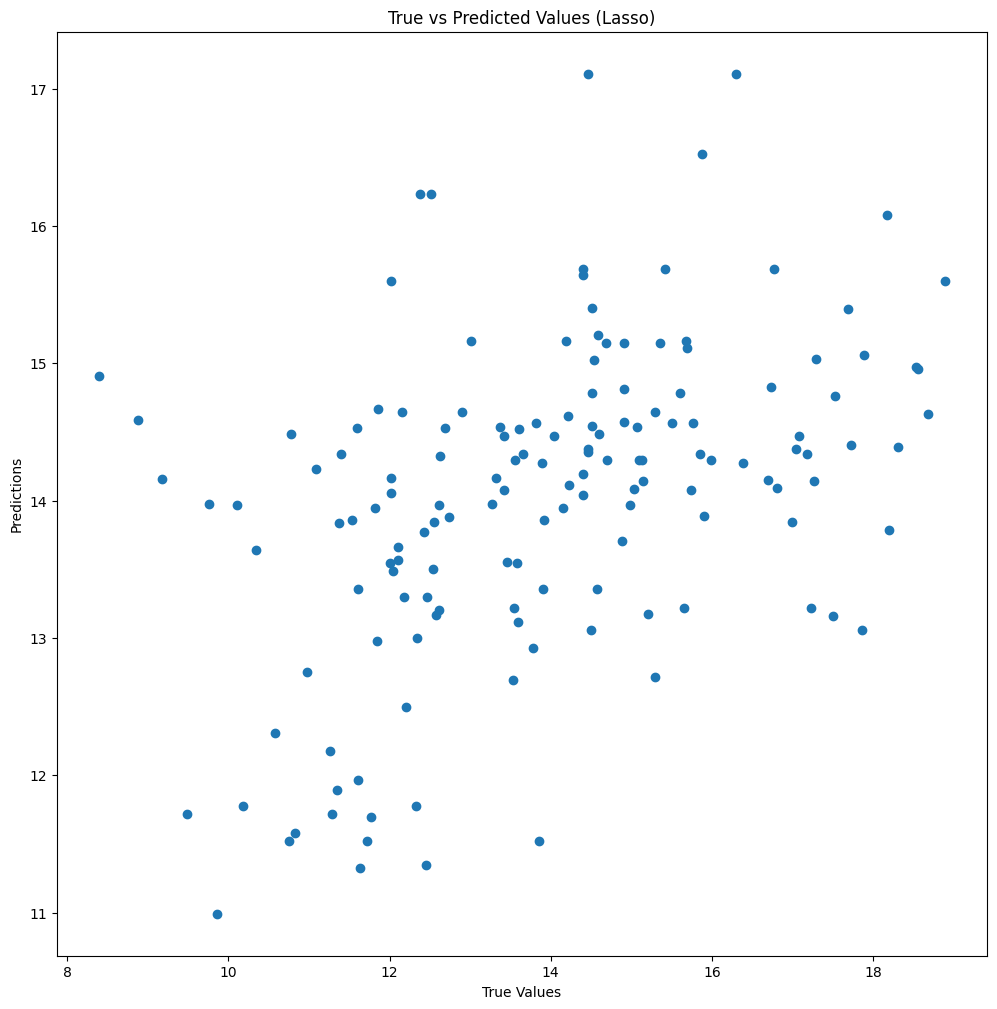

In [45]:
# Visualize the results: Plot the actual vs predicted values
ax = plt.subplots(figsize=(12,12))[1]
plt.scatter(y_test, y_pred_best)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values (Lasso)")
plt.show()

In [46]:
############################## Lasso regression on full dataset ############################

# Fit Lasso regression on the full dataset with the optimal alpha (lambda)
lasso_full = Lasso(alpha=best_alpha)  # Use the best alpha found in cross-validation
lasso_full.fit(X_scaled, y)

# Get the coefficients of the full model
lasso_full_coef = lasso_full.coef_
print(f"Lasso coefficients for full dataset: {lasso_full_coef}")


Lasso coefficients for full dataset: [ 0.          0.50684358  0.15426894  0.00668594 -0.20372653 -0.20026062
 -0.53108751 -0.26360147  0.15213784 -0.7967194  -0.16017186 -0.1963266
  0.01219406 -0.29338201 -0.15821795 -0.21907107  0.20218847  0.70983078
  0.6848881   0.45227711]
